# Lecture 11e. Polynomial regression and regularization

> 🎓 **Status: Optional / career-track.** Not walked through in class. Not required for the next lecture. Covers required-track-adjacent material a data-science career will need; beginners can defer it.

## A real problem this technique solves

Lectures 11a and 11b fit **straight lines** through data — one slope per feature, plus an intercept.  
That works beautifully when the underlying relationship really is a line.  
But many relationships that matter in business and science are *curves* — they bend, they peak, they bottom out.  
A straight line through such data is wrong in a way that no amount of extra data will fix.

**Polynomial regression** is the smallest extension that lets a linear model learn curves: feed it not just `x` but also `x^2`, `x^3`, and so on.

## Three places polynomial regression earns its keep

- **Dose-response curves in pharmacology** — drug effect is almost never linear in dose. The curve rises steeply at low doses, slows as receptors saturate, then plateaus (or falls, if the drug becomes toxic). A polynomial in dose captures the rising-then-plateauing shape; a straight line over-predicts at low doses and under-predicts at the plateau.
- **Energy demand vs outdoor temperature** — load is high at low temperatures (heating) and at high temperatures (cooling); mild weather is the minimum. The relationship is **U-shaped**. A linear fit averages the two ends and gets the middle wrong; a degree-2 polynomial captures the U.
- **Production cost vs output volume** — average cost per unit falls as a factory scales (economies of scale), then rises past some point (overtime, bottlenecks, coordination cost). The cost-volume curve is U- or J-shaped, and managers price products from such curves.

## What this notebook covers

- **§B** — Synthetic 1-D demo. As polynomial degree grows, the fit goes from underfitting → good → overfitting. Produces the classic bias-variance *scissors* plot.
- **§C** — *Regularization* as the cure for overfitting. Meet **Ridge** (L2 penalty, shrinks coefficients) and **Lasso** (L1 penalty, zeros coefficients out).
- **§D** — Real multivariate dataset (California housing). Compare plain linear regression, polynomial + linear, polynomial + Ridge, polynomial + Lasso.
- **§E** — Picking the regularization strength `alpha` *honestly*, with a three-way train/validation/test split.
- **§F** — What is coming in lecture 13 (cross-validation, `RidgeCV`, `LassoCV`, ElasticNet, tree-based regressors).

## What this notebook deliberately leaves for later

- `Pipeline`, `GridSearchCV`, `RidgeCV`, `LassoCV`, `cross_validate` — **all** lecture 13 territory. We build manual pipelines here so the steps stay visible.
- Cross-validation in general — lecture 13.
- Tree-based regressors and gradient boosting — lectures 13 and 14.
- The full derivation of the Ridge/Lasso objectives — we state the loss; we do not differentiate it.

## Primer — what are the L1 and L2 norms?

§C introduces **Ridge** and **Lasso**, two regularised variants of linear regression.  
Both add a *penalty* to the squared-error loss; the penalty is a **norm** of the coefficient vector — a measure of how "big" that vector is.  
Ridge and Lasso differ only in *which* norm they use:

- **Ridge** uses the **(squared) L2 norm**.
- **Lasso** uses the **L1 norm**.

This section defines both, gives the intuition, and points to where they appear later.

### Definitions

For a coefficient vector `β = (β₁, β₂, …, β_p)`:

| Norm | Formula | Verbal description |
| --- | --- | --- |
| **L1** | `‖β‖₁ = |β₁| + |β₂| + … + |β_p|` | Sum of absolute values. The *taxicab* or *Manhattan* distance — length of a path along a city grid. |
| **L2** | `‖β‖₂ = √(β₁² + β₂² + … + β_p²)` | Square root of the sum of squares. The ordinary *Euclidean* length — straight-line distance from the origin. |
| **squared L2** | `‖β‖₂² = β₁² + β₂² + … + β_p²` | The square of the above. Ridge uses *this* form because dropping the square root makes the math (and the gradient) cleaner. |

Both are zero only when `β = 0`, and both grow as coefficients move away from zero — so both serve the role of "the bigger the coefficients, the bigger the penalty".

### Geometric intuition — why L1 yields zeros and L2 does not

Picture the set of vectors with norm ≤ 1 — the *unit ball* of each norm in two dimensions:

- The **L2** unit ball is a **circle** — smooth everywhere, no special directions.
- The **L1** unit ball is a **diamond** (rotated square) with corners *on the axes*. Those corners are where one coordinate is exactly zero.

When regression squeezes the optimum toward the origin under a penalty, it slides along a level curve until it touches the constraint ball.  
A round L2 ball touches at a generic point — all coefficients shrink, none hit zero.  
A diamond-shaped L1 ball touches preferentially at a *corner* — the optimum lands on an axis, with one coordinate driven to exactly zero.  
That is **sparsity** — Lasso's defining property, geometric in origin.

### Where the norms appear in this notebook

- **§C2 — Ridge** minimises `RSS + α · ‖β‖₂²`. All coefficients shrink smoothly; none reach zero.
- **§C4 — Lasso** minimises `RSS + α · ‖β‖₁`. Some coefficients are pushed to *exactly* zero — Lasso does feature selection for you.
- **§D / §E — California housing** revisits both norms on a multivariate, real-world dataset.
- **`lec_11f §C` — ElasticNet** uses **L1 + L2 together** for cases where pure L1 is too aggressive about dropping correlated features.

The numpy cell below computes all three norms on a small example so the formulas connect to running code before you meet them in `Ridge` and `Lasso`.


In [31]:
import numpy as np

# A toy 5-coefficient vector. Think of beta as the slopes a regression has just
# fit on 5 features. Two of them are large, one is near zero, one is exactly
# zero. Different norms summarise this vector's "size" differently.
beta = np.array([3.0, -4.0, 0.5, 0.0, -1.5])

l1    = np.sum(np.abs(beta))         # L1 norm: sum of |coefficients|
l2    = np.sqrt(np.sum(beta ** 2))   # L2 norm: Euclidean length
l2_sq = np.sum(beta ** 2)            # squared L2 -- what Ridge actually penalises

print(f"beta              = {beta}")
print(f"|beta_j| per coef = {np.abs(beta)}")
print(f"beta_j^2 per coef = {beta ** 2}")
print()
print(f"||beta||_1        = {l1:>7.4f}   # L1   = sum of |beta_j|")
print(f"||beta||_2        = {l2:>7.4f}   # L2   = sqrt(sum of beta_j^2)")
print(f"||beta||_2^2      = {l2_sq:>7.4f}   # Ridge penalises THIS (no sqrt)")

# Sanity check: setting any one coefficient to zero reduces both norms.
# Zeroing the largest (-4.0) drops L1 by 4 and L2^2 by 16 -- the L2 penalty
# punishes a big coefficient roughly four times more than a coefficient of
# half the size, while L1 punishes them only twice as much. That asymmetry
# is exactly why L2 spreads shrinkage across all coefficients while L1 prefers
# to zero out the smaller ones.
beta_dropped = beta.copy()
beta_dropped[1] = 0.0
print()
print(f"after zeroing beta[1] = -4.0:")
print(f"  ||beta||_1  = {np.sum(np.abs(beta_dropped)):.4f}   (dropped {l1 - np.sum(np.abs(beta_dropped)):.2f})")
print(f"  ||beta||_2^2 = {np.sum(beta_dropped ** 2):.4f}   (dropped {l2_sq - np.sum(beta_dropped ** 2):.2f})")


beta              = [ 3.  -4.   0.5  0.  -1.5]
|beta_j| per coef = [3.  4.  0.5 0.  1.5]
beta_j^2 per coef = [ 9.   16.    0.25  0.    2.25]

||beta||_1        =  9.0000   # L1   = sum of |beta_j|
||beta||_2        =  5.2440   # L2   = sqrt(sum of beta_j^2)
||beta||_2^2      = 27.5000   # Ridge penalises THIS (no sqrt)

after zeroing beta[1] = -4.0:
  ||beta||_1  = 5.0000   (dropped 4.00)
  ||beta||_2^2 = 11.5000   (dropped 16.00)


## B. A one-dimensional demo: when does a polynomial overfit?

We will generate clean synthetic data where the **truth** is known — `y = sin(2*pi*x) + noise` — and watch what happens as we fit polynomials of higher and higher degree. With the truth in hand, we can show exactly when the model is too rigid (underfit) and exactly when it has started memorising noise (overfit).


### Imports and the random-state constant

A single imports cell, near the top of the notebook, makes the dependencies obvious. `RANDOM_STATE = 42` is the seed we pass to every random operation that supports one. *Note*: `LinearRegression`, `Ridge`, `Lasso`, `PolynomialFeatures`, and `StandardScaler` do **not** take a `random_state` argument — they are deterministic given their inputs.


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


### B1. Generate the synthetic data

The true relationship is `y = sin(2*pi*x)`. We add Gaussian noise with standard deviation `0.2` so the points scatter around the curve without hiding it. We use `np.random.default_rng(RANDOM_STATE)` rather than the older `np.random.seed`, because the new generator is the recommended NumPy 2.x interface.


In [33]:
rng = np.random.default_rng(RANDOM_STATE)

n_samples = 50
x = rng.uniform(0.0, 1.0, size=n_samples)
noise = rng.normal(0.0, 0.2, size=n_samples)
y = np.sin(2 * np.pi * x) + noise

# x must be a column vector for sklearn — it expects 2D feature arrays.
X = x.reshape(-1, 1)

X.shape, y.shape


((50, 1), (50,))

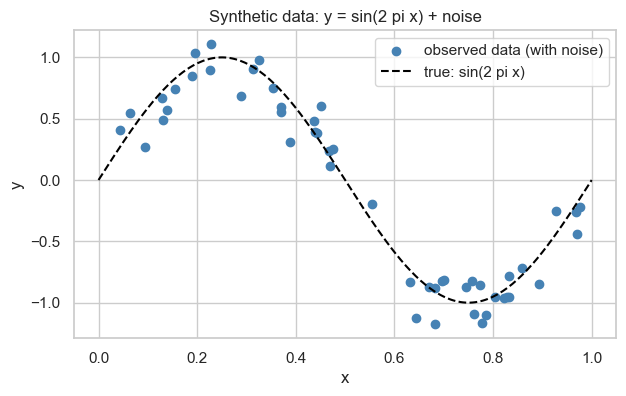

In [34]:
# Plot the data against the true sin curve, so we can see what a "perfect" model would look like.
x_grid = np.linspace(0.0, 1.0, 200).reshape(-1, 1)
y_true_grid = np.sin(2 * np.pi * x_grid).ravel()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, color="steelblue", label="observed data (with noise)")
ax.plot(x_grid, y_true_grid, color="black", linestyle="--", label="true: sin(2 pi x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Synthetic data: y = sin(2 pi x) + noise")
ax.legend()
plt.show()


### B2. What `PolynomialFeatures` actually does

`PolynomialFeatures(degree=N)` takes a column of `x` values and returns a matrix whose columns are `[1, x, x^2, ..., x^N]` — the original feature, plus every power up to `N`. Once we have that matrix, *ordinary linear regression* fits a coefficient for each column. The model is still **linear in its coefficients** (which is why it is called *linear* regression even though the resulting curve is bent) — it is just being fed nonlinear features.

The cell below makes the expansion concrete on three sample points.


In [35]:
poly_demo = PolynomialFeatures(degree=3)
sample_points = np.array([[0.0], [0.5], [1.0]])
expanded = poly_demo.fit_transform(sample_points)

pd.DataFrame(
    expanded,
    columns=poly_demo.get_feature_names_out(["x"]),
    index=[f"x = {row[0]}" for row in sample_points],
)


,1,x,x^2,x^3
x = 0.0,1.0,0.0,0.00,0.000
x = 0.5,1.0,0.5,0.25,0.125
x = 1.0,1.0,1.0,1.00,1.000


### B3. Fit polynomials of several degrees on the same data

We fit polynomials of degree 1, 3, 5, 9, and 15 on the **same** training points, then draw each fitted curve over the true sin curve. As the degree climbs, the curve becomes more flexible — at first that helps (degree 3 is much closer to the truth than degree 1), but eventually the curve starts chasing individual data points (degree 15).


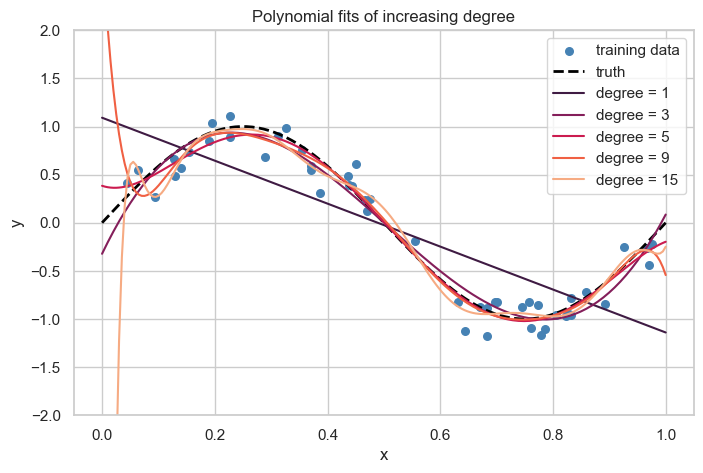

In [36]:
degrees = [1, 3, 5, 9, 15]

# A fine grid for drawing the fitted curves smoothly.
x_grid = np.linspace(0.0, 1.0, 200).reshape(-1, 1)
y_true_grid = np.sin(2 * np.pi * x_grid).ravel()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="steelblue", s=30, label="training data")
ax.plot(x_grid, y_true_grid, color="black", linestyle="--", linewidth=2, label="truth")

palette = sns.color_palette("rocket", n_colors=len(degrees))

for degree, colour in zip(degrees, palette):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    X_grid_poly = poly.transform(x_grid)

    model = LinearRegression()
    model.fit(X_poly, y)
    y_grid_pred = model.predict(X_grid_poly)

    ax.plot(x_grid, y_grid_pred, color=colour, label=f"degree = {degree}")

ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Polynomial fits of increasing degree")
ax.legend()
plt.show()


### B4. Quantify the overfit — train MSE vs test MSE across degrees

The plot above suggests degree 3-5 is close to the truth and degree 15 is overfitting.  
To **quantify** that, split the data into train (70%) and test (30%), refit each polynomial on the training set, and measure mean squared error on both sets.

Expectation:

- **Train MSE** falls monotonically as degree increases — a more flexible model can always fit the training points better.
- **Test MSE** falls at first (the curve approximates the truth better), then *rises* again (the curve starts chasing training noise that is not present in the test set).

The crossing point — where train keeps falling but test starts rising — is the visual signature of overfitting.  
The shape of the two curves is sometimes called the *bias-variance scissors*.


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)


In [38]:
degree_sweep = list(range(1, 16))
train_mse_per_degree = []
test_mse_per_degree = []

for degree in degree_sweep:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_mse_per_degree.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_mse_per_degree.append(mean_squared_error(y_test, model.predict(X_test_poly)))

mse_table = pd.DataFrame(
    dict(degree=degree_sweep, train_mse=train_mse_per_degree, test_mse=test_mse_per_degree)
)
mse_table


,degree,train_mse,test_mse
0,1,0.153142,0.265024
1,2,0.151479,0.262472
2,3,0.021714,0.047151
3,4,0.020494,0.052408
4,5,0.017793,0.034642
5,6,0.017667,0.035636
6,7,0.015410,0.049763
7,8,0.014675,0.048594
8,9,0.013789,0.054700
9,10,0.013765,0.047924


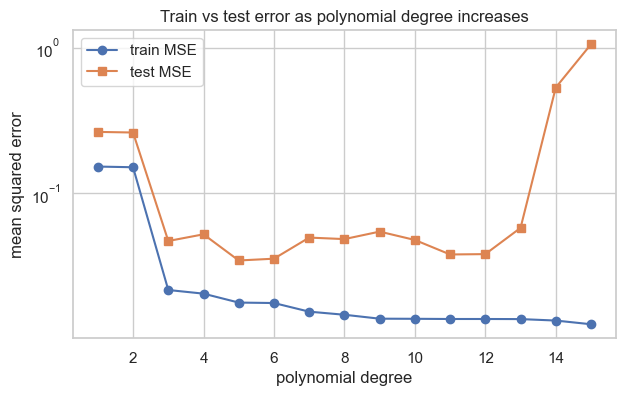

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(degree_sweep, train_mse_per_degree, marker="o", label="train MSE")
ax.plot(degree_sweep, test_mse_per_degree, marker="s", label="test MSE")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("mean squared error")
ax.set_title("Train vs test error as polynomial degree increases")
ax.set_yscale("log")
ax.legend()
plt.show()


### B5. Reading the scissors plot

- **Low degree (1-2)** — *underfitting*. Too rigid to capture the sine wave; train and test MSE are both high. A *bias* problem.
- **Middle degree (around 3-5)** — *good fit*. Test MSE bottoms out. Flexible enough to track the truth, not flexible enough to chase noise.
- **High degree (10+)** — *overfitting*. Train MSE keeps dropping, but test MSE climbs sharply. The model memorises the specific noise pattern of the training points. A *variance* problem.

The lesson generalises far beyond polynomials: every machine-learning model has a *capacity* knob (degree here, depth in trees, hidden units in neural nets), and the test-error curve is almost always U-shaped in that knob.


## C. Regularization — keeping a flexible model honest

§B's answer to overfitting was *use a smaller degree*. That works, but it is a blunt instrument — we throw away all of the model's flexibility, including the flexibility we needed.

**Regularization** is more surgical:

- Keep the flexible model (degree 15 stays).
- Penalise the model for producing large coefficients.

The intuition:  
an overfitting polynomial has enormous, wildly-oscillating coefficients — billion-sized positives cancelling against billion-sized negatives to draw those squiggles.  
A penalty that prefers small coefficients forces the optimiser to find a smoother fit.


### C1. The deg-15 coefficients are huge

Before we apply any regularization, let us look at what an unregularized degree-15 polynomial is actually doing under the hood. We refit it on the full data, then plot its 16 coefficients (including the intercept) as a bar chart.


In [40]:
poly_15 = PolynomialFeatures(degree=15)
X_poly_15 = poly_15.fit_transform(X)

unreg_model = LinearRegression()
unreg_model.fit(X_poly_15, y)

coef_names = poly_15.get_feature_names_out(["x"])
unreg_coefs = pd.Series(unreg_model.coef_, index=coef_names)
unreg_coefs


1       0.000000e+00
x       1.614054e+03
x^2    -4.443016e+04
x^3     6.737384e+05
x^4    -6.400698e+06
x^5     4.096413e+07
x^6    -1.845110e+08
x^7     6.007640e+08
x^8    -1.435736e+09
x^9     2.533692e+09
x^10   -3.292117e+09
x^11    3.107419e+09
x^12   -2.071128e+09
x^13    9.236300e+08
x^14   -2.472421e+08
x^15    3.003497e+07
dtype: float64

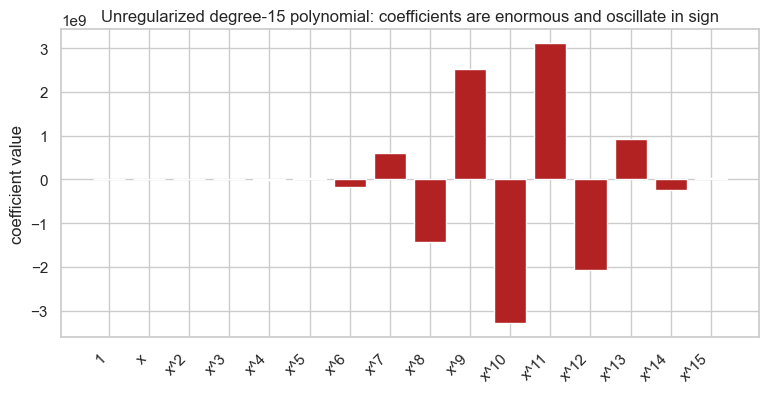

In [41]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(unreg_coefs)), unreg_coefs.values, color="firebrick")
ax.set_xticks(range(len(unreg_coefs)))
ax.set_xticklabels(coef_names, rotation=45, ha="right")
ax.set_ylabel("coefficient value")
ax.set_title("Unregularized degree-15 polynomial: coefficients are enormous and oscillate in sign")
plt.show()


Notice the scale on the y-axis — coefficients in the *thousands* or larger, alternating positive and negative. This is the fingerprint of an overfitting polynomial.


### C2. Ridge regression (L2 penalty)

Ridge regression minimises:

`RSS + alpha * sum(beta_j ** 2)`

— squared-error loss **plus** a penalty proportional to the squared sum of the coefficients (the L2 norm).

- `alpha` controls how strong the penalty is.
- `alpha = 0` reproduces plain linear regression.
- Very large `alpha` shrinks all coefficients toward zero.

Why does this fight overfitting?  
Large coefficients become *expensive*, so the optimiser prefers smoother fits whose coefficients are modest.  
Ridge will not zero coefficients out exactly — it just makes them small.

**Scaling matters.** Polynomial features `x, x^2, ..., x^15` differ by enormous magnitudes on `[0, 1]` (the column for `x^15` is microscopic).  
The L2 penalty treats every coefficient on an equal footing, so we must put every feature column on a comparable scale first.  
`StandardScaler` does that — subtract the mean, divide by the standard deviation of each column.


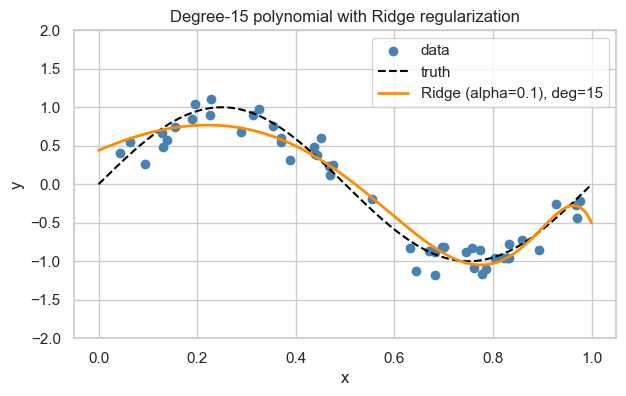

In [43]:
# Scale the polynomial features so the L2 penalty is fair across columns.
scaler_15 = StandardScaler()
X_poly_15_scaled = scaler_15.fit_transform(X_poly_15)

ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_poly_15_scaled, y)

# Predict on a fine grid for plotting.
x_grid = np.linspace(0.0, 1.0, 200).reshape(-1, 1)
X_grid_poly_15 = poly_15.transform(x_grid)
X_grid_poly_15_scaled = scaler_15.transform(X_grid_poly_15)
y_grid_ridge = ridge_model.predict(X_grid_poly_15_scaled)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, color="steelblue", label="data")
ax.plot(x_grid, np.sin(2 * np.pi * x_grid).ravel(), color="black", linestyle="--", label="truth")
ax.plot(x_grid, y_grid_ridge, color="darkorange", linewidth=2, label="Ridge (alpha=0.1), deg=15")
ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Degree-15 polynomial with Ridge regularization")
ax.legend()
plt.show()


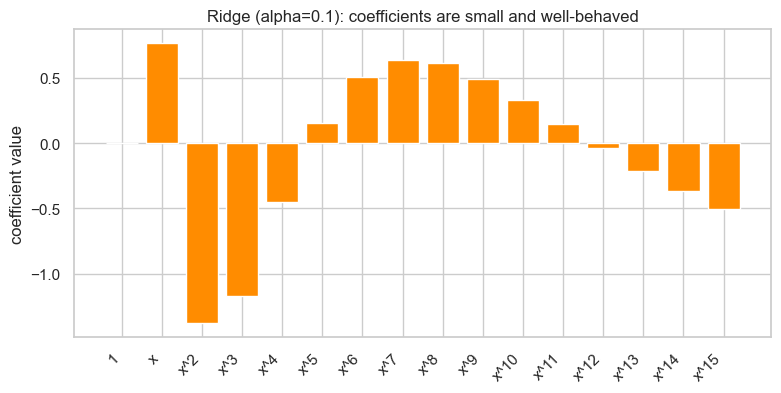

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(ridge_model.coef_)), ridge_model.coef_, color="darkorange")
ax.set_xticks(range(len(coef_names)))
ax.set_xticklabels(coef_names, rotation=45, ha="right")
ax.set_ylabel("coefficient value")
ax.set_title("Ridge (alpha=0.1): coefficients are small and well-behaved")
plt.show()


### C3. Sweep `alpha` for Ridge

What does `alpha` actually do to the fit? Three values across four orders of magnitude:

- `alpha = 0.001` — almost no penalty, the fit will be wiggly (close to unregularized).
- `alpha = 0.1` — moderate penalty, the fit should track the sin curve well.
- `alpha = 10` — strong penalty, the fit becomes too flat (the penalty has overwhelmed the data).


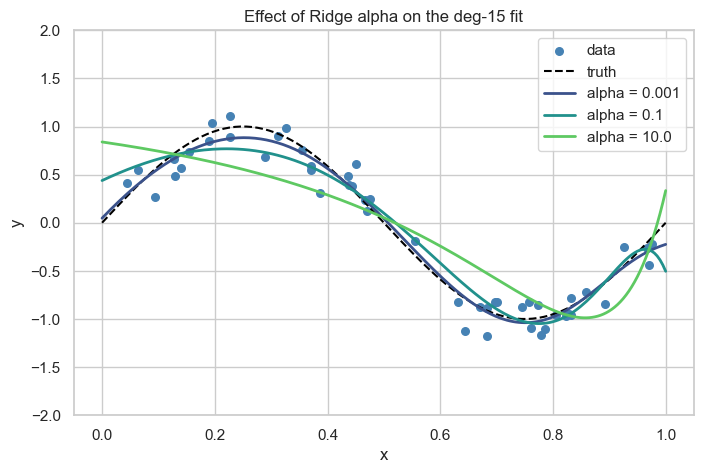

In [45]:
alphas_to_try = [0.001, 0.1, 10.0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color="steelblue", s=30, label="data")
ax.plot(x_grid, np.sin(2 * np.pi * x_grid).ravel(), color="black", linestyle="--", label="truth")

palette = sns.color_palette("viridis", n_colors=len(alphas_to_try))

for alpha_value, colour in zip(alphas_to_try, palette):
    model = Ridge(alpha=alpha_value)
    model.fit(X_poly_15_scaled, y)
    y_grid_pred = model.predict(X_grid_poly_15_scaled)
    ax.plot(x_grid, y_grid_pred, color=colour, linewidth=2, label=f"alpha = {alpha_value}")

ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Effect of Ridge alpha on the deg-15 fit")
ax.legend()
plt.show()


### C4. Lasso regression (L1 penalty)

Lasso minimises:

`RSS + alpha * sum(|beta_j|)`

— squared-error loss **plus** the sum of the absolute values of the coefficients (the L1 norm).  
Same idea as Ridge — penalise large coefficients — but with a different penalty shape that has a remarkable consequence:  
many coefficients are pushed all the way to **exactly zero**. The fit literally drops features.

This is called **sparsity**.  
Lasso effectively does feature selection for you — the features whose coefficients survive are the ones the model considers useful; the rest are zeroed out.

**A practical note on convergence.** Lasso is optimised by coordinate descent (not closed-form like Ridge), and it can fail to converge in the default 1000 iterations on poorly-scaled polynomial features.  
The fix is to raise `max_iter`. We pass `max_iter=10000` here, which is enough for this problem.  
Convergence warnings can show up on harder problems — a higher `max_iter`, or feature scaling, usually fixes them.


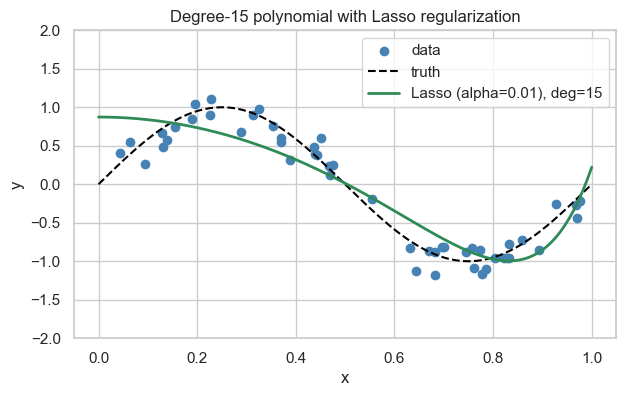

In [46]:
lasso_model = Lasso(alpha=0.01, max_iter=10000)
lasso_model.fit(X_poly_15_scaled, y)

y_grid_lasso = lasso_model.predict(X_grid_poly_15_scaled)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, color="steelblue", label="data")
ax.plot(x_grid, np.sin(2 * np.pi * x_grid).ravel(), color="black", linestyle="--", label="truth")
ax.plot(x_grid, y_grid_lasso, color="seagreen", linewidth=2, label="Lasso (alpha=0.01), deg=15")
ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Degree-15 polynomial with Lasso regularization")
ax.legend()
plt.show()


Nonzero coefficients: 3 / 16


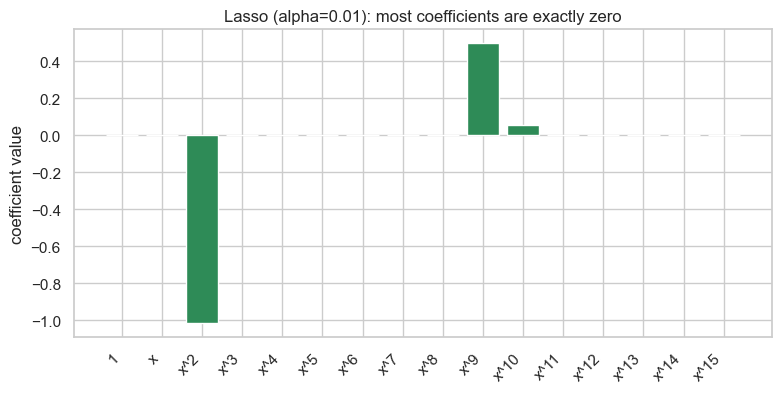

In [47]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(lasso_model.coef_)), lasso_model.coef_, color="seagreen")
ax.set_xticks(range(len(coef_names)))
ax.set_xticklabels(coef_names, rotation=45, ha="right")
ax.set_ylabel("coefficient value")
ax.set_title("Lasso (alpha=0.01): most coefficients are exactly zero")

n_nonzero = int(np.sum(lasso_model.coef_ != 0))
n_total = len(lasso_model.coef_)
print(f"Nonzero coefficients: {n_nonzero} / {n_total}")
plt.show()


> **⏱ Skip if running long.** The geometry of why Lasso zeros coefficients. The rest of the notebook reuses Lasso without depending on this intuition.


### C5. Why does L1 zero coefficients but L2 does not?

Imagine the unregularized best-fit coefficient vector as a point in coefficient space. The penalty term shrinks that point toward the origin.

- **L2** (`sum(beta**2)`) — level sets are *circles* (or higher-dimensional balls), smooth and rounded. Shrinkage proceeds smoothly along the circle; coefficients get small but typically not exactly zero.
- **L1** (`sum(|beta|)`) — level sets are *diamonds* with sharp corners exactly on the axes. Shrinkage tends to land at those corners, and a corner on an axis means *that coefficient is zero*.

That is the geometric reason Lasso produces sparse solutions and Ridge does not.  
(The worked geometric picture is a standard topic in statistical-learning textbooks; this paragraph is all we need here.)


## D. A real multivariate example — California housing

Synthetic 1-D demos make the story crisp, but the real value of polynomial regression and regularization shows up in **multivariate** problems with many features.

We use the **California housing** dataset that ships with scikit-learn:

- 20 640 census blocks.
- 8 features per block — median income, house age, average rooms, average bedrooms, population, average occupancy, latitude, longitude.
- Target: median house value in units of $100 000.

Polynomial expansion of 8 features at degree 2 produces *many* more columns:  
8 originals + 8 squares + 28 pairwise interactions = **44 columns** (without the bias).  
This is where regularization stops being a textbook curiosity and starts mattering in practice.


In [48]:
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame
df_housing.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [49]:
X_housing = housing.data    # DataFrame: 8 numeric features
y_housing = housing.target  # Series:    median house value in $100 000

X_housing.shape, y_housing.shape


((20640, 8), (20640,))

In [50]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=RANDOM_STATE
)
X_train_h.shape, X_test_h.shape


((16512, 8), (4128, 8))

### D1. Plain linear regression on the 8 raw features

This is the baseline — no polynomial features, no regularization. We expect a modest test R^2 (the relationship between income/location/etc. and house price is not perfectly linear).


In [63]:
linreg_plain = LinearRegression()
linreg_plain.fit(X_train_h, y_train_h)

train_r2_plain = r2_score(y_train_h, linreg_plain.predict(X_train_h))
test_r2_plain = r2_score(y_test_h, linreg_plain.predict(X_test_h))

print(f"Plain linear regression train R^2: {train_r2_plain:.4f}")
print(f"Plain linear regression test  R^2: {test_r2_plain:.4f}")


Plain linear regression train R^2: 0.6126
Plain linear regression test  R^2: 0.5758


### D2. Polynomial expansion + linear regression

Add **degree-2 polynomial features** — every original feature plus every squared term plus every pairwise interaction.  
We pass `include_bias=False` because `LinearRegression` already fits its own intercept; otherwise we would have two intercept columns.

The pipeline is **manual** and the order matters:

1. `PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_train)` — expand training features.
2. `StandardScaler().fit(X_train_poly)` — fit the scaler **only on the training expansion**.
3. Apply the *same* polynomial and scaler to the test set with `.transform(...)`. Never re-`fit` on the test set.
4. Fit `LinearRegression` on the scaled expanded features.

Why scale *after* the polynomial expansion?  
Squared and product features can blow up to huge magnitudes (`Population^2`, `Population * AveRooms`), and we want them on a comparable scale before the model sees them.  
This will matter even more for Ridge and Lasso below.


In [64]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly2.fit_transform(X_train_h)
X_test_poly = poly2.transform(X_test_h)

scaler_housing = StandardScaler()
X_train_poly_scaled = scaler_housing.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_housing.transform(X_test_poly)

print(f"Original number of features:        {X_train_h.shape[1]}")
print(f"After degree-2 polynomial expansion: {X_train_poly.shape[1]}")


Original number of features:        8
After degree-2 polynomial expansion: 44


In [ ]:
linreg_poly = LinearRegression()
linreg_poly.fit(X_train_poly_scaled, y_train_h)

train_r2_poly = r2_score(y_train_h, linreg_poly.predict(X_train_poly_scaled))
test_r2_poly = r2_score(y_test_h, linreg_poly.predict(X_test_poly_scaled))
print(f"Polynomial (deg=2) + LinearRegression train R^2: {train_r2_poly:.4f}")
print(f"Polynomial (deg=2) + LinearRegression test  R^2: {test_r2_poly:.4f}")


Polynomial (deg=2) + LinearRegression train R^2: 0.6853
Polynomial (deg=2) + LinearRegression test  R^2: 0.6457


### D3. Polynomial + Ridge

The polynomial expansion improved the train fit but the gap between train and test can widen — that is the overfitting signature again. Ridge should shrink the gap.


In [66]:
ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(X_train_poly_scaled, y_train_h)

train_r2_ridge = r2_score(y_train_h, ridge_poly.predict(X_train_poly_scaled))
test_r2_ridge = r2_score(y_test_h, ridge_poly.predict(X_test_poly_scaled))

print(f"Polynomial (deg=2) + Ridge(alpha=1.0) train R^2: {train_r2_ridge:.4f}")
print(f"Polynomial (deg=2) + Ridge(alpha=1.0) test  R^2: {test_r2_ridge:.4f}")


Polynomial (deg=2) + Ridge(alpha=1.0) train R^2: 0.6694
Polynomial (deg=2) + Ridge(alpha=1.0) test  R^2: 0.6391


### D4. Polynomial + Lasso

Lasso brings the *bonus feature* — sparsity. After fitting, we count how many of the polynomial coefficients are exactly zero. Lasso has, in effect, performed feature selection: only the features with non-zero coefficients made the cut.

Lasso on polynomial features can take many iterations; we pass `max_iter=20000` to be safe.


In [ ]:
lasso_poly = Lasso(alpha=0.01, max_iter=20000)
lasso_poly.fit(X_train_poly_scaled, y_train_h)

train_r2_lasso = r2_score(y_train_h, lasso_poly.predict(X_train_poly_scaled))
test_r2_lasso = r2_score(y_test_h, lasso_poly.predict(X_test_poly_scaled))

n_nonzero_lasso = int(np.sum(lasso_poly.coef_ != 0))
n_total_lasso = len(lasso_poly.coef_)

print(f"Polynomial (deg=2) + Lasso(alpha=0.01) train R^2: {train_r2_lasso:.4f}")
print(f"Polynomial (deg=2) + Lasso(alpha=0.01) test  R^2: {test_r2_lasso:.4f}")
print(f"Nonzero coefficients: {n_nonzero_lasso} / {n_total_lasso}")


Polynomial (deg=2) + Lasso(alpha=0.01) train R^2: 0.6140
Polynomial (deg=2) + Lasso(alpha=0.01) test  R^2: 0.5715
Nonzero coefficients: 16 / 44


In [ ]:
results_table = pd.DataFrame(
    dict(
        model=[
            "Linear (raw 8 features)",
            "Linear + poly(deg=2)",
            "Ridge(alpha=1) + poly(deg=2)",
            "Lasso(alpha=0.01) + poly(deg=2)",
        ],
        train_r2=[train_r2_plain, train_r2_poly, train_r2_ridge, train_r2_lasso],
        test_r2=[test_r2_plain, test_r2_poly, test_r2_ridge, test_r2_lasso],
    )
)
results_table["gap"] = results_table["train_r2"] - results_table["test_r2"]
results_table


,model,train_r2,test_r2,gap
0,Linear (raw 8 features),0.612551,0.575788,0.036763
1,Linear + poly(deg=2),0.685268,0.645682,0.039586
2,Ridge(alpha=1) + poly(deg=2),0.669386,0.639133,0.030253
3,Lasso(alpha=0.01) + poly(deg=2),0.613951,0.571523,0.042429


### D5. What the comparison table says

- **Polynomial expansion** improves over plain linear regression — the relationship between features and price has real curvature and interactions.
- **Ridge** keeps almost all of the polynomial gain in test R^2 while shrinking the train-vs-test gap. The polynomial-Ridge combination is the everyday workhorse for tabular regression problems with moderate non-linearity.
- **Lasso** zeros out a sizeable chunk of the 44 features. The resulting model is **interpretable** — you can list the features it actually uses — at a small cost in fit quality, traded off via `alpha`.

The takeaway is the same trade-off you saw in §B: more flexibility helps until it starts hurting, and regularization is the standard knob for finding the sweet spot.


> **⏱ Skip if running long.** The mechanic for picking `alpha` with a validation set. The fixed `alpha = 1.0` used in §D is fine for class demonstration; lecture 13 will replace this with cross-validation.


## E. Picking `alpha` honestly — train / validation / test

In §D we picked `alpha = 1.0` and `alpha = 0.01` out of thin air. In a real project you have to **choose** `alpha`.

The natural-but-wrong approach:  
try several values, pick whichever scores best on the test set, and report that test score.  
The problem — that test score is no longer an honest estimate of how the model performs on new data, because you already used the test set *to pick the model*. You have, in effect, fit `alpha` to the test set.

The fix is a **three-way split**:

- **Train set** — fit each candidate model.
- **Validation set** — score each candidate; pick the best `alpha`.
- **Test set** — touched **once**, at the very end, to report the final number.

Lecture 10 introduced the basic two-way split; this is the upgrade.  
Lecture 13 will replace the single validation set with k-fold cross-validation, but the spirit is identical:  
do not pick the model on the same data you use to report its final score.


### E1. Carve out the three sets

We do `train_test_split` twice — first to peel off the test set (20%), then to split the remaining 80% into train (60% of the original) and validation (20% of the original).


In [57]:
# First split: peel off the test set.
X_trainval, X_test_final, y_trainval, y_test_final = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=RANDOM_STATE
)

# Second split: divide the rest into train and validation.
# 0.25 of 0.8 == 0.2 of the original total.
X_train_e, X_val_e, y_train_e, y_val_e = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Train:      {X_train_e.shape[0]}")
print(f"Validation: {X_val_e.shape[0]}")
print(f"Test:       {X_test_final.shape[0]}")


Train:      12384
Validation: 4128
Test:       4128


### E2. Expand and scale — fit on train only

The polynomial and scaler are fit on the **training** data only, then applied (via `.transform`) to the validation and test sets. Re-fitting on the validation or test sets would leak information.


In [58]:
poly_e = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_e = poly_e.fit_transform(X_train_e)
X_val_poly_e   = poly_e.transform(X_val_e)
X_test_poly_e  = poly_e.transform(X_test_final)

scaler_e = StandardScaler()
X_train_poly_e_scaled = scaler_e.fit_transform(X_train_poly_e)
X_val_poly_e_scaled   = scaler_e.transform(X_val_poly_e)
X_test_poly_e_scaled  = scaler_e.transform(X_test_poly_e)

X_train_poly_e_scaled.shape, X_val_poly_e_scaled.shape, X_test_poly_e_scaled.shape


((12384, 44), (4128, 44), (4128, 44))

### E3. Sweep `alpha` and pick the best on validation


In [59]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
val_r2_per_alpha = []

for alpha_value in alphas:
    model = Ridge(alpha=alpha_value)
    model.fit(X_train_poly_e_scaled, y_train_e)
    val_r2 = r2_score(y_val_e, model.predict(X_val_poly_e_scaled))
    val_r2_per_alpha.append(val_r2)

alpha_table = pd.DataFrame(dict(alpha=alphas, val_r2=val_r2_per_alpha))
alpha_table


,alpha,val_r2
0,0.001,0.425899
1,0.010,0.543033
2,0.100,-1.327531
3,1.000,-7.942189
4,10.000,-10.532019
5,100.000,-5.157386


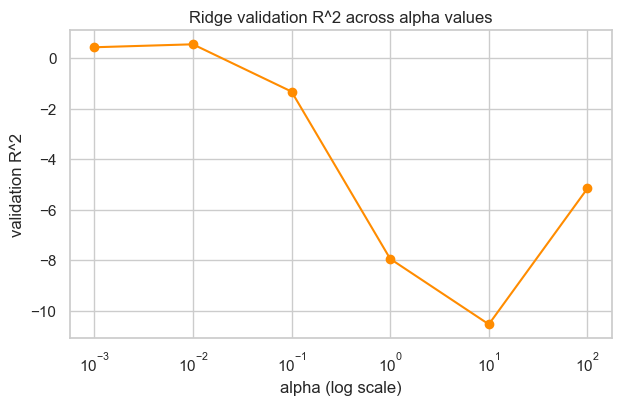

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, val_r2_per_alpha, marker="o", color="darkorange")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("validation R^2")
ax.set_title("Ridge validation R^2 across alpha values")
plt.show()


In [61]:
best_index = int(np.argmax(val_r2_per_alpha))
best_alpha = alphas[best_index]
best_val_r2 = val_r2_per_alpha[best_index]
print(f"Best alpha by validation R^2: {best_alpha}")
print(f"Validation R^2 at best alpha: {best_val_r2:.4f}")


Best alpha by validation R^2: 0.01
Validation R^2 at best alpha: 0.5430


### E4. Refit on train + validation, then evaluate on test — once

With `alpha` chosen, we use as much data as possible to fit the final model — that means **train + validation combined**. We then touch the test set exactly once to report the final R^2.

This is the honest number to put in a slide deck. The validation R^2 above is optimistic (it is the one we picked); the test R^2 below has not influenced any of our choices.


In [62]:
# Refit polynomial and scaler on (train + val), then evaluate on the held-out test set.
X_trainval_poly = poly_e.fit_transform(X_trainval)
X_test_poly_final = poly_e.transform(X_test_final)

scaler_final = StandardScaler()
X_trainval_poly_scaled = scaler_final.fit_transform(X_trainval_poly)
X_test_poly_final_scaled = scaler_final.transform(X_test_poly_final)

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_trainval_poly_scaled, y_trainval)

final_test_r2 = r2_score(y_test_final, final_model.predict(X_test_poly_final_scaled))
print(f"Final honest test R^2 (Ridge, alpha={best_alpha}): {final_test_r2:.4f}")


Final honest test R^2 (Ridge, alpha=0.01): 0.6666


### E5. The rule

> The validation set picks the hyperparameter. The test set gives you the one honest final number.

If a stakeholder asks *"how well does the model do on new data?"* — the answer is the **test R^2** computed above, not the validation R^2 you used to pick `alpha`.

Lecture 13 replaces the single validation set with k-fold cross-validation, which is more data-efficient (every observation gets to be in the validation set once), and shows how `RidgeCV`, `LassoCV`, and `GridSearchCV` automate the whole sweep.


## F. What's next (lecture 13 and beyond)

This notebook deliberately stopped short of several standard tools. Here are the previews — you will work each one in lecture 13.

### ElasticNet — combine L1 and L2

ElasticNet minimises:

`RSS + alpha * (l1_ratio * sum(|beta|) + (1 - l1_ratio) * sum(beta ** 2))`

A tunable mixture of Lasso and Ridge. The motivation:

- When features are highly correlated, **Lasso** picks *one* feature from the correlated group arbitrarily and zeros the rest.
- **Ridge** keeps them all but shrinks them.
- **ElasticNet** keeps the group together (Ridge-like) while still producing some sparsity (Lasso-like).

It is the standard choice when you want both feature selection and stability. The worked example is in lecture 13.

### Cross-validation — replace the single validation set

The three-way split in §E uses one validation set, so the choice of `alpha` depends on the luck of that one split.

**K-fold cross-validation** rotates the validation role through K different chunks of the data and averages the validation scores. It is more data-efficient and more stable.

Lecture 13 introduces:

- `cross_validate` — generic CV scoring.
- `RidgeCV`, `LassoCV` — built-in CV for the two regularisers we met here.
- `GridSearchCV` — general-purpose hyperparameter search combined with cross-validation.

### Beyond linear-in-features — trees and boosting

Polynomial regression has a hard ceiling — you have to *say* which non-linear features to engineer (squares, products, …).  
For complex non-linearities and high-cardinality categorical features, models that *learn* the non-linearity from the data tend to win:

- **Regression trees** — lecture 13.
- **Random forests** — lecture 14.
- **Gradient-boosted regressors** (`GradientBoostingRegressor`, XGBoost, LightGBM) — lecture 14. The production default for tabular regression in 2026.

For now, the toolkit you have after this lecture — linear regression, polynomial expansion, Ridge, Lasso, train/validation/test discipline — is enough to ship a real regression model and explain it honestly.
